In [ ]:
import sys as _sys
from pathlib import Path as _Path
try:
    _sys.path.insert(0, str(_Path(__vsc_ipynb_file__).parent.parent))
except NameError:
    pass  # Not in VS Code; rely on pip install -e .

import os
from scripts.utils import setup_notebook, OKABE_ITO_CYCLE

PROJECT_ROOT, np, pd, plt, Path = setup_notebook()

# Backward-compatible alias: cells below reference color_values[i]
color_values = OKABE_ITO_CYCLE

In [ ]:
RAW_DATA_DIR = PROJECT_ROOT / "data" / "Theoretical calculations by Helen"
PLOTS_DIR    = PROJECT_ROOT / "figures"
PLOTS_DIR.mkdir(exist_ok=True)

In [8]:
excel_path = os.path.join(RAW_DATA_DIR,"CrSBr_hysteresis_calculation.xlsx")
excel_file = pd.ExcelFile(excel_path)

# Parse the first sheet
df = excel_file.parse(sheet_name='Sheet1')

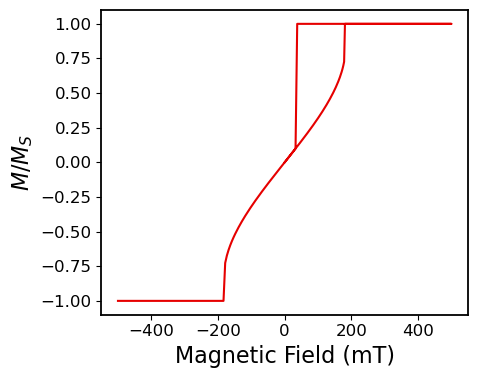

In [4]:

# Clean and extract the relevant data
data = df.iloc[1:, :2]  # Skip the header row and keep first two columns
data.columns = ["Magnetic field (mT)", "Magnetization (rel. units)"]
data = data.dropna().astype(float)

plt.figure(figsize=(5, 4))
plt.plot(data["Magnetic field (mT)"], data["Magnetization (rel. units)"], linewidth=1.5, color =color_values[0])
plt.xlabel("Magnetic Field (mT)")
plt.ylabel("$M/M_{S}$")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "Theory_CrSBr_c_axes.png"), dpi = 600)

plt.show()


In [ ]:
# Load Excel file
crsbr_excel_path = os.path.join(RAW_DATA_DIR, "CrSBr_hysteresis_13052025.xlsx")
crsbr_excel = pd.ExcelFile(crsbr_excel_path)

# Read the first sheet
df = crsbr_excel.parse(crsbr_excel.sheet_names[0])

# Extract and clean the first two columns
data = df.iloc[1:, :2]
data.columns = ["Magnetic field (mT)", "Magnetization (rel. units)"]
data = data.dropna().astype(float)

plt.figure(figsize=(5, 4))
plt.plot(data["Magnetic field (mT)"], data["Magnetization (rel. units)"], linewidth=1.5, color =color_values[0])
plt.xlabel("Magnetic Field (mT)")
plt.ylabel("$M/M_{S}$")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "Theory_CrSBr_c_axes.png"), dpi = 600)


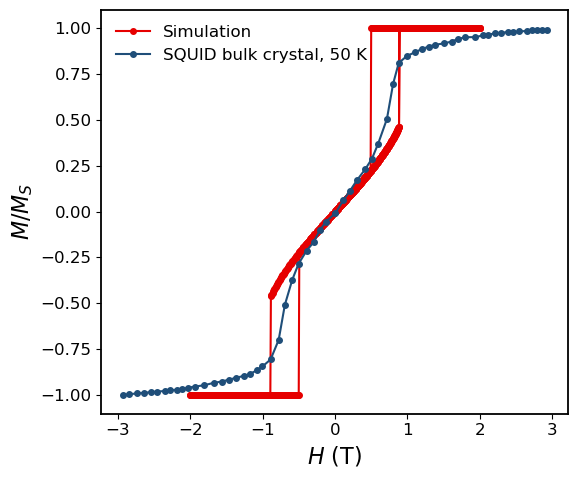

In [13]:


# === Set file path ===
file_path = os.path.join(RAW_DATA_DIR, "CrSBr_hysteresis_SQUID_literature_comparison.xlsx")

# === Read all sheets with appropriate headers ===
# Assuming that row 3 in Excel (index=2) contains the actual headers
sheet1 = pd.read_excel(file_path, sheet_name=0, header=1)
sheet2 = pd.read_excel(file_path, sheet_name=1, header=1)
sheet3 = pd.read_excel(file_path, sheet_name=2, header=1)

# === Clean and rename columns ===

sheet1['Field'] = sheet1['Field'] * 1e-3  # Convert mT to Tesla
sheet3['Field'] = sheet3['Field'] # Convert Oe to Tesla

# === Plotting ===
plt.figure(figsize=(6, 5))

plt.plot(sheet1['Field'], sheet1['M/MS'], '-o', label='Simulation', linewidth=1.5, color=color_values[0])
plt.plot(sheet2['Field'], sheet2['M/MS'], '-o', label='SQUID bulk crystal, 50 K', linewidth=1.5, color=color_values[1])
#plt.plot(sheet3['Field'], sheet3['M/MS'], '-o', label='SQUID', linewidth=1.5, color=color_values[2])
plt.legend(frameon=False)
plt.xlabel('$H$ (T)')
plt.ylabel('$M/M_{S}$')
plt.tight_layout()

# === Save the plot ===
output_path = os.path.join(PLOTS_DIR,"Theory_CrSBr_c_axes.png")
plt.savefig(output_path, dpi=600, transparent=True)
plt.show()
